In [1]:
%%capture
%pip install qldpc
%pip install matplotlib
%pip install tqec

# Decoding TQEC Circuits

[TQEC](https://github.com/tqec/tqec) compiles lattice surgery operations into physical circuits that implement the corresponding logical operations in logical qubits of the surface code. This notebook demonstrates using a decoder from qLDPC to decode circuits compiled and simulated by TQEC. This notebook is adapted from the [TQEC notebooks](https://github.com/tqec/tqec/tree/main/docs/gallery).

## Background: TQEC circuits and observables

`tqec` provides builtin functions to construct simple example computations in `tqec.gallery`. You define your own lattice surgery operations using `tqec.BlockGraph` (not shown here).

In [2]:
import tqec
import tqec.gallery

block_graph = tqec.gallery.cnot(tqec.Basis.Z)
block_graph.view_as_html()

We can use the `find_correlation_surfaces()` method to identify a generating set of correlation surfaces (which correspond to `stim` observables), and then visualize these correlation surfaces using the `view_as_html()` method.  We show one correlation surface below.

In [3]:
correlation_surfaces = block_graph.find_correlation_surfaces()
block_graph.view_as_html(
    pop_faces_at_directions=("-Y",),
    show_correlation_surface=correlation_surfaces[0],
)

## Simulation

Here we simulate all observables under uniform depolarizing noise model using qLDPC's decoders.  TQEC's `start_simulation_using_sinter` is a wrapper around its compiler and `sinter`, so it accepts compilation arguments and `sinter`'s simulation arguments.  Arguments like `save_resume_filepath` may come in handy when the simulation is computationally intensive.

### imports, simulations and plotting code

In [4]:
import numpy as np
import sinter
from tqec import NoiseModel
from tqec.simulation.simulation import start_simulation_using_sinter
from typing import Sequence

import matplotlib.pyplot as plt
import sinter
from tqec.simulation.plotting.inset import plot_observable_as_inset

from qldpc import circuits, decoders

In [5]:
zx_graph = block_graph.to_zx_graph()  # for highlighting the correlation surfaces in the ZX diagram


def get_simulation_data(
    block_graph: tqec.BlockGraph,
    distances: Sequence[int],
    decoders: sinter.Decoder | Sequence[sinter.Decoder],
    error_rates: Sequence[float] = list(np.logspace(-3, -2, 5)),
    max_shots: int = 10**5,
    max_errors: int = 100,
) -> list[list[list[sinter.TaskStats]]]:
    """."""
    if isinstance(decoders, sinter.Decoder):
        # use the same decoder for all distances
        custom_decoders = {str(dist): decoders for dist in distances}
    else:
        # match each provided distance to a provided decoder
        assert len(distances) == len(decoders)
        custom_decoders = {str(dist): decoder for dist, decoder in zip(distances, decoders)}
    return [
        start_simulation_using_sinter(
            block_graph,
            [dist // 2],  # ???
            error_rates,
            circuits.DepolarizingNoiseModel, # can also be NoiseModel.uniform_depolarizing
            manhattan_radius=2,
            observables=correlation_surfaces,
            max_shots=max_shots,
            max_errors=max_errors,
            decoders=[str(dist)],  # specify a custom decoder by name
            custom_decoders=custom_decoders,  # decoder name -> decoder
            print_progress=True,
        )
        for dist in distances
    ]



def plot(stats: list[list[list[sinter.TaskStats]]]):
    for i, stat in enumerate(zip(*stats)):
        _, ax = plt.subplots()
        sinter.plot_error_rate(
            ax=ax,
            stats=sum(stat, []),
            x_func=lambda s: s.json_metadata["p"],
            failure_units_per_shot_func=lambda s: s.json_metadata["d"],
            group_func=lambda s: s.json_metadata["d"],
        )
        tqec.simulation.plotting.inset.plot_observable_as_inset(ax, zx_graph, correlation_surfaces[i])
        ax.grid(axis="both")
        ax.loglog()
        ax.set_xlabel("physical error rate")
        ax.set_ylabel("logical error rate")
        ax.legend(loc="best")

## Surface code with minimum-weight perfect matching (MWPM)

We plot the logical error rate of each observable separately.

In [6]:
distances = [3, 5, 7]
decoder = decoders.SinterDecoder(with_MWPM=True, ignore_non_graphlike_errors=True)
mwpm_stats = get_simulation_data(block_graph, distances, decoder)

Starting 16 workers...
5 tasks left:
  workers decoder eta shots_left errors_left json_metadata                  
        3       3   ?     100000         100 d=3,r=3,p=0.001                
        3       3 30m      99999         100 d=3,r=3,p=0.0017782794100389228
        3       3   ?     100000         100 d=3,r=3,p=0.0031622776601683794
        3       3   ?     100000         100 d=3,r=3,p=0.005623413251903491 
        4       3   ?     100000         100 d=3,r=3,p=0.01                 
3 tasks left:
  workers decoder        eta shots_left errors_left json_metadata                  
        6       3        <1m      97679          90 d=3,r=3,p=0.001                
        7       3        <1m      91671          46 d=3,r=3,p=0.0017782794100389228
        3       3 [draining]      94811         -12 d=3,r=3,p=0.0031622776601683794
3 tasks left:
  workers decoder        eta shots_left errors_left json_metadata                  
        6       3        <1m      97679          90 d

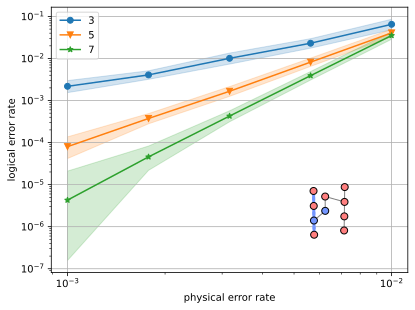

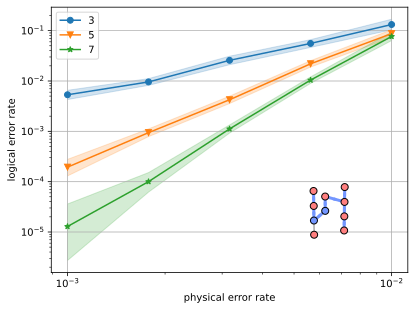

In [7]:
plot(mwpm_stats)

## Sliding Window Decoding

Now we switch to sliding window decoders.

In [8]:
# We define the sliding window decoder for each code distance
distances = [3, 5, 7]
decoders = [
    decoders.SlidingWindowDecoder(
        dist,
        dist // 2,
        with_MWPM=True,
        ignore_non_graphlike_errors=True,
    )
    for dist in distances
]
sliding_window_mwpm_stats = get_simulation_data(block_graph, distances, decoders)

Starting 16 workers...
5 tasks left:
  workers decoder eta shots_left errors_left json_metadata                  
        3       3   ?     100000         100 d=3,r=3,p=0.001                
        3       3 19m      99999         100 d=3,r=3,p=0.0017782794100389228
        3       3   ?     100000         100 d=3,r=3,p=0.0031622776601683794
        3       3   ?     100000         100 d=3,r=3,p=0.005623413251903491 
        4       3   ?     100000         100 d=3,r=3,p=0.01                 
5 tasks left:
  workers decoder eta shots_left errors_left json_metadata                  
        3       3 <1m      99863          99 d=3,r=3,p=0.001                
        3       3 <1m      98703          87 d=3,r=3,p=0.0017782794100389228
        3       3 22m      99998         100 d=3,r=3,p=0.0031622776601683794
        3       3 <1m      99863          96 d=3,r=3,p=0.005623413251903491 
        4       3   ?     100000         100 d=3,r=3,p=0.01                 
5 tasks left:
  workers d

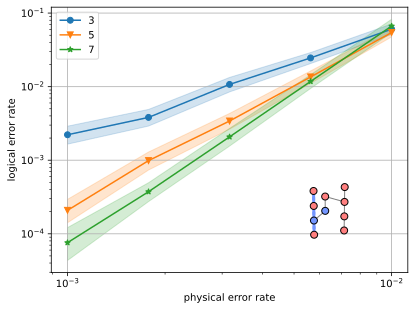

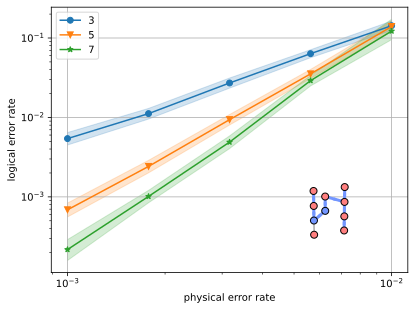

In [9]:
plot(sliding_window_mwpm_stats)